# Naive Bayes: A Comprehensive Guide

Naive Bayes is a family of probabilistic classifiers based on Bayes' theorem with the 'naive' assumption that features are conditionally independent given the class label. Despite this simplification, it often performs surprisingly well.

In this notebook, we'll cover:
1. Basic concepts of Naive Bayes
2. Data preparation and visualization
3. Model implementation from scratch (Gaussian Naive Bayes)
4. Using scikit-learn for Naive Bayes
5. Model evaluation and interpretation

# Simple Explanation: What Does the Code Below Do?

Imagine you receive an email and want to know if it's spam. You look at the words in the email. Words like 'FREE', 'WINNER', 'CLICK HERE' are more common in spam. Naive Bayes calculates the probability that the email is spam given all the words it contains.

**Bayes' Theorem**: P(Spam|words) = P(words|Spam) × P(Spam) / P(words)

The 'naive' part: It assumes each word's probability of being in spam/not spam is independent of the other words. This isn't always true, but it makes calculations much simpler!

Here's what the code does:
1. Loads the Iris dataset for multi-class classification.
2. Implements Gaussian Naive Bayes from scratch.
3. Uses scikit-learn's Naive Bayes variants (Gaussian, Multinomial, Bernoulli).
4. Evaluates performance and compares variants.

In short: Naive Bayes uses probability and Bayes' theorem to make predictions fast and efficiently!

In [1]:
# Create a virtual environment and install required libraries
import os
import sys

venv_dir = 'ml_env'
if not os.path.exists(venv_dir):
    os.system(f'{sys.executable} -m venv {venv_dir}')
    print(f'Virtual environment created at {venv_dir}')
else:
    print(f'Virtual environment already exists at {venv_dir}')

pip_path = os.path.join(venv_dir, 'Scripts', 'pip')
if sys.platform == 'win32':
    pip_path += '.exe'

if os.path.exists(pip_path):
    os.system(f'"{pip_path}" install numpy pandas matplotlib seaborn scikit-learn')
    print('Required libraries installed in the virtual environment.')
else:
    print('Could not find pip in the virtual environment. Please check your Python installation.')

Virtual environment already exists at ml_env
Required libraries installed in the virtual environment.


# 1. Required Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# 2. Generating Sample Data

Dataset shape: (150, 4)


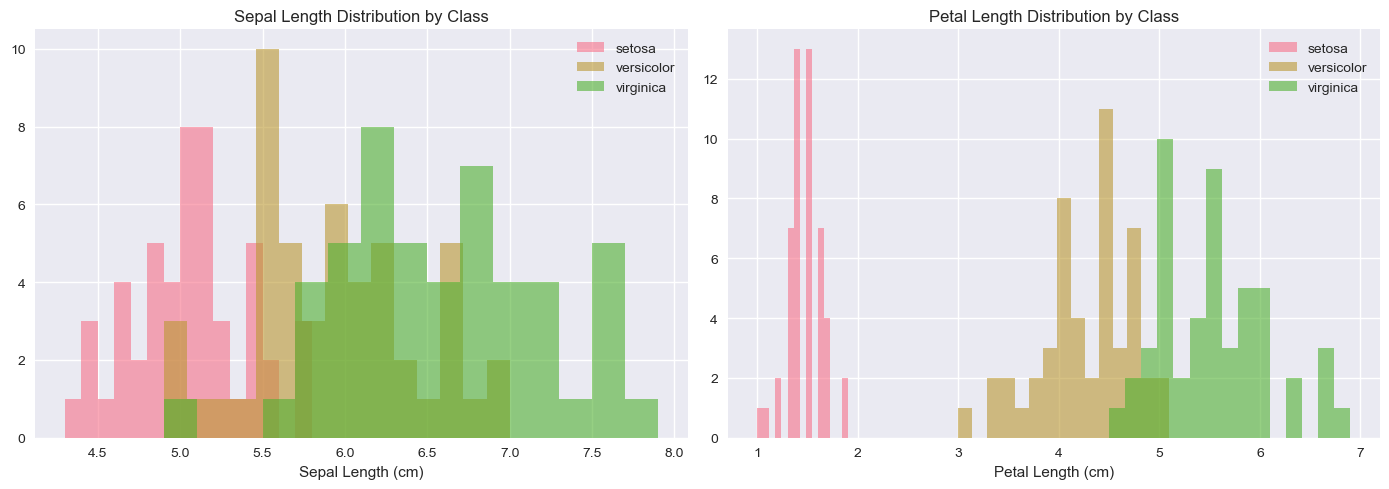

In [3]:
iris = load_iris()
X, y = iris.data, iris.target
class_names = iris.target_names
feature_names = iris.feature_names

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print('Dataset shape:', X.shape)
# Visualize feature distributions per class
df = pd.DataFrame(X, columns=feature_names)
df['species'] = [class_names[i] for i in y]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for cls in class_names:
    subset = df[df['species'] == cls]
    axes[0].hist(subset['sepal length (cm)'], alpha=0.6, label=cls, bins=15)
axes[0].set_title('Sepal Length Distribution by Class')
axes[0].set_xlabel('Sepal Length (cm)')
axes[0].legend()

for cls in class_names:
    subset = df[df['species'] == cls]
    axes[1].hist(subset['petal length (cm)'], alpha=0.6, label=cls, bins=15)
axes[1].set_title('Petal Length Distribution by Class')
axes[1].set_xlabel('Petal Length (cm)')
axes[1].legend()

plt.tight_layout()
plt.show()

# 3. Implementing Gaussian Naive Bayes from Scratch

For continuous features, we model P(feature|class) as a Gaussian (normal) distribution:
- For each class, compute the mean and variance of each feature.
- At prediction time, use the Gaussian probability density function.
- Combine probabilities across all features (naive assumption: they're independent).

In [4]:
class GaussianNaiveBayesScratch:
    def __init__(self):
        self.classes = None
        self.mean = {}    # mean of each feature per class
        self.var = {}     # variance of each feature per class
        self.prior = {}   # P(class)

    def fit(self, X, y):
        self.classes = np.unique(y)
        for c in self.classes:
            X_c = X[y == c]
            self.mean[c] = X_c.mean(axis=0)
            self.var[c] = X_c.var(axis=0)
            self.prior[c] = len(X_c) / len(X)

    def _gaussian_pdf(self, x, mean, var):
        """Gaussian probability density function."""
        eps = 1e-9  # small value for numerical stability
        coeff = 1 / np.sqrt(2 * np.pi * (var + eps))
        exponent = np.exp(-0.5 * ((x - mean) ** 2) / (var + eps))
        return coeff * exponent

    def _log_posterior(self, x, c):
        """Compute log P(c|x) ∝ log P(x|c) + log P(c)"""
        log_prior = np.log(self.prior[c])
        log_likelihood = np.sum(np.log(self._gaussian_pdf(x, self.mean[c], self.var[c])))
        return log_prior + log_likelihood

    def predict(self, X):
        return np.array([self.classes[np.argmax([self._log_posterior(x, c) for c in self.classes])] 
                         for x in X])

gnb_scratch = GaussianNaiveBayesScratch()
gnb_scratch.fit(X_train, y_train)
y_pred_scratch = gnb_scratch.predict(X_test)
print(f'Gaussian NB (Scratch) Accuracy: {accuracy_score(y_test, y_pred_scratch):.4f}')

Gaussian NB (Scratch) Accuracy: 1.0000


# 4. Using Scikit-learn's Naive Bayes

Scikit-learn provides several Naive Bayes variants:
- **GaussianNB**: For continuous data (assumes Gaussian distribution)
- **MultinomialNB**: For discrete counts (e.g., text classification word counts)
- **BernoulliNB**: For binary features

In [5]:
# Gaussian NB
gnb = GaussianNB()
gnb.fit(X_train, y_train)
y_pred = gnb.predict(X_test)

print(f'GaussianNB Accuracy: {accuracy_score(y_test, y_pred):.4f}')
print(f'\nClassification Report:\n{classification_report(y_test, y_pred, target_names=class_names)}')

# Show learned parameters
print('\nLearned class means (first 2 features):')
for i, cls in enumerate(class_names):
    print(f'  {cls}: sepal_length={gnb.theta_[i,0]:.2f}, sepal_width={gnb.theta_[i,1]:.2f}')

GaussianNB Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30


Learned class means (first 2 features):
  setosa: sepal_length=4.99, sepal_width=3.45
  versicolor: sepal_length=5.92, sepal_width=2.77
  virginica: sepal_length=6.53, sepal_width=2.97


# 5. Model Evaluation

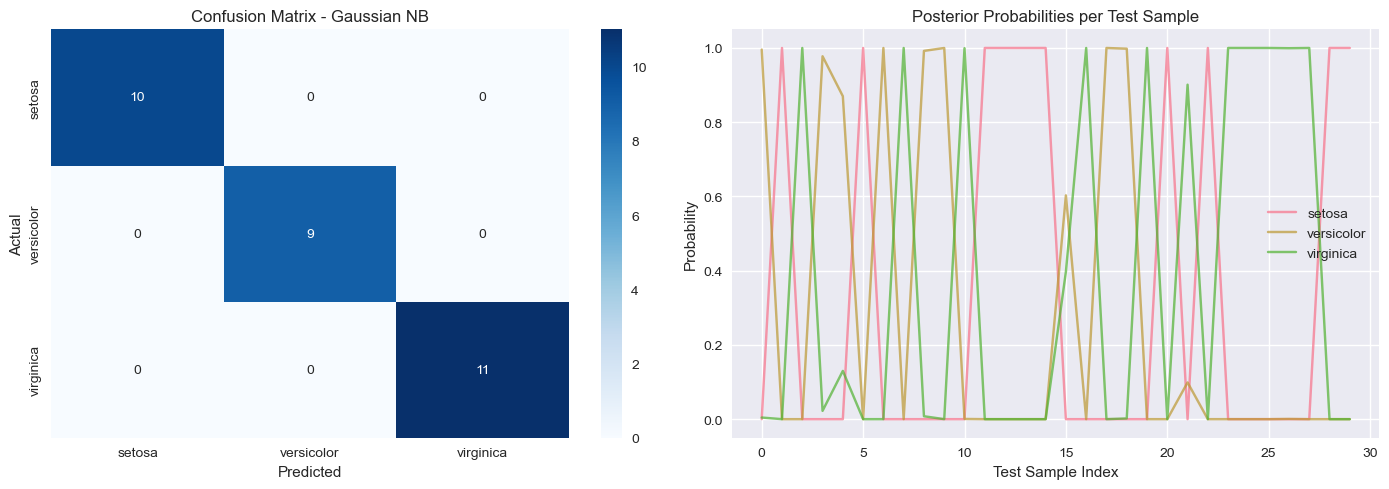


Key Insights:
- Naive Bayes is fast, simple, and works well with small datasets.
- GaussianNB: Best for continuous features.
- MultinomialNB: Best for text classification (word counts).
- Despite the naive independence assumption, it often performs well in practice!


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, 
            yticklabels=class_names, ax=axes[0])
axes[0].set_title('Confusion Matrix - Gaussian NB')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# 2. Probability calibration - visualize posterior probabilities
y_proba = gnb.predict_proba(X_test)
x_pos = np.arange(len(y_test))
for i, cls in enumerate(class_names):
    axes[1].plot(x_pos, y_proba[:, i], label=cls, alpha=0.7)
axes[1].set_title('Posterior Probabilities per Test Sample')
axes[1].set_xlabel('Test Sample Index')
axes[1].set_ylabel('Probability')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

print('\nKey Insights:')
print('- Naive Bayes is fast, simple, and works well with small datasets.')
print('- GaussianNB: Best for continuous features.')
print('- MultinomialNB: Best for text classification (word counts).')
print('- Despite the naive independence assumption, it often performs well in practice!')

# Conclusions and Key Takeaways
Naive Bayes is a family of probabilistic algorithms based on applying Bayes' theorem with the "naive" assumption of conditional independence between every pair of features given the value of the class variable.
- **Fast and Scalable**: Extremely fast to train and predict, making it highly scalable for massive datasets.
- **Text Classification**: Due to its ability to handle high-dimensional, sparse data, it's exceptionally popular for NLP tasks like spam filtering and sentiment analysis.
- Despite the "naive" assumption often being wrong in the real world, the algorithm still performs surprisingly well, especially for classification.

# Pros and Cons
**Pros:**
- Computationally very fast; needs only a single pass through the data.
- Needs less training data than many complex models (like deep learning) if the independence assumption holds.
- Native multi-class prediction without resorting to One-vs-Rest algorithms.
- Works exceptionally well with high-dimensional datasets.

**Cons:**
- The assumption of independent features is almost never true in real-world data (e.g., in text, the word "New" heavily affects the probability of the word "York").
- Poor estimator: while it ranks classes well (classifying them correctly), the actual probability outputs from `predict_proba` are often highly inaccurate and overconfident.
- Zero Frequency Problem: If a categorical variable has a category in the test dataset that wasn't observed in the training data, the model will assign it a probability of zero, nullifying the entire prediction.

# 15 Interview Questions and Answers

1. **What is Bayes' Theorem?**
   *Answer*: It describes the probability of an event, based on prior knowledge of conditions that might be related to the event. P(A|B) = [P(B|A) * P(A)] / P(B).

2. **Why is Naive Bayes considered "Naive"?**
   *Answer*: Because it assumes that all features are mutually independent given the class label. In reality, features are almost always correlated (e.g., age and salary).

3. **If the independence assumption is completely wrong, why does Naive Bayes still work so well for classification?**
   *Answer*: For classification, we only care about which class has the maximum probability, not the exact, precisely calibrated probability value. Even if the probabilities are heavily skewed by correlated features, the maximum probability often still points to the correct class.

4. **What is Multinomial Naive Bayes?**
   *Answer*: A variant used primarily for discrete data such as text classification. It models the data using a multinomial distribution (e.g., word counts or term frequencies).

5. **What is Gaussian Naive Bayes?**
   *Answer*: A variant used when dealing with continuous data. It assumes that the continuous values associated with each class are distributed according to a normal (Gaussian) distribution.

6. **What is Bernoulli Naive Bayes?**
   *Answer*: A variant designed for binary/boolean features (e.g., does a word appear in the document: yes or no). 

7. **What is the "Zero Frequency Problem" (Zero Probability)?**
   *Answer*: If a specific feature value never occurs together with a specific class in the training data, the algorithm assigns it a zero probability. Because naive bayes multiplies all probabilities together, this single zero turns the entire posterior probability to zero.

8. **How do you fix the Zero Frequency Problem?**
   *Answer*: By using Laplace Smoothing (or Additive Smoothing). You add a small pseudocount (usually alpha=1) to all feature frequencies so that no probability is ever exactly zero.

9. **Does Naive Bayes require feature scaling?**
   *Answer*: No. Standard Naive Bayes doesn't use distance metrics or gradient descent, so the scale of the features does not affect the outcome. (Gaussian NB calculates variance relative to the feature's own scale).

10. **How does Naive Bayes handle missing data?**
    *Answer*: It handles it quite well natively. If a feature value is missing for an instance, Naive Bayes simply omits that probability from the calculation and multiplies the probabilities of the observed features.

11. **Why is Naive Bayes often used as a baseline model for NLP?**
    *Answer*: Because text data is incredibly high-dimensional and sparse. Complex algorithms like SVMs or Neural Networks take a massive amount of time to train on such data, while Naive Bayes establishes a very fast, decent performance benchmark in seconds.

12. **Is Naive Bayes a generative or discriminative model?**
    *Answer*: It is a Generative model. It learns the joint probability distribution P(X,Y) and models exactly how the data was generated for each class, unlike Discriminative models (like Logistic Regression) which only learn the boundary P(Y|X) between classes.

13. **How do correlated features negatively impact Naive Bayes?**
    *Answer*: Because the algorithm assumes independence, it essentially "double-counts" the evidence provided by highly correlated features, making the algorithm overly confident in its prediction.

14. **What is the time complexity of training Naive Bayes?**
    *Answer*: It is roughly O(N * D) where N is the number of samples and D is the number of features. It simply passes through the data to count frequencies, making it fundamentally O(N).

15. **Can you interpret the coefficients/probabilities in Naive Bayes?**
    *Answer*: Yes, you can examine the conditional probabilities P(Feature | Class) to see exactly which features are the strongest evidence for a particular class (e.g., seeing that the word "Viagra" has a 95% probability of occurring in a spam email).
